In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
data = xr.open_dataarray('../data/processed-full.nc')

In [169]:
diffs = {}
for mid, m in enumerate(data.month.values):
    mdata = data.sel(date=(data.month==m)).stack(d=['date','number']).reset_index('d')
    arr = np.zeros_like(mdata.values)
    ref = np.sort(mdata.isel(time=0).values)
    for tid in range(len(data.time.values)):
        vals = mdata.isel(time=tid).values
        vals = np.sort(vals)
        arr[tid] = vals - ref
    diffs[m] = mdata.copy(data=arr)

In [186]:
months = {5:"may", 6:"june", 7:"july", 8:"august", 9:"september", 10:"october"}
for m in range(6,11):
    da = diffs[m]
    for tid in range(len(da.time.values)):
        da[1,tid,:] = np.sort(da.isel(var=1, time=tid).values)
    diffs[m] = da.drop_vars(['date', 'number', 'month'])
    diffs[m].to_netcdf(
        months[m]+'_diffs.nc'
    )

In [257]:
def grad(X, y, theta, n=1):
    return 2 / n * X.T.dot(X.dot(theta) - y)

def sdg(X, y, step, nb, batch_size):
    
    cost_history = []
    
    m = len(X)
    X = np.c_[np.ones((m,1)), X]
    if len(y.shape)==1:
        y = y.reshape((len(y),1))
    
    theta = np.random.randn(3,1)
    
    for i in range(nb):
        rng = np.random.default_rng()
        indices = rng.choice(m, batch_size)
        X_batch = X[indices]
        y_batch = y[indices]
        
        theta -= step*grad(X_batch, y_batch, theta, batch_size)
        assert not (np.any(np.isnan(theta)) or np.any(np.isinf(theta))), "nan stop"
        
        if i%1000 == 0:
            risk = np.nanmean((X.dot(theta)-y)**2)
            cost_history.append(risk)
    
    return theta, cost_history

In [ ]:
def gd(X, y, step, nb):
    
    cost_history = []
    
    m = len(X)
    if len(y.shape)==1:
        y = y.reshape((len(y),1))
    
    theta = np.random.randn(2,1)
    
    for i in range(nb):
        theta -= step*grad(X, y, theta, m)
        assert not (np.any(np.isnan(theta)) or np.any(np.isinf(theta))), "nan stop"
        
        if i%100 == 0 and i!=0:
            risk = np.nanmean((X.dot(theta)-y)**2)
            cost_history.append(risk)
    
    return theta, cost_history

In [188]:
da = xr.open_dataarray('may_diffs.nc')

In [189]:
da

<xarray.DataArray 'tp24' (var: 2, time: 29, obj: 37485)> Size: 17MB
[2174130 values with dtype=float64]
Coordinates:
  * var      (var) <U4 32B 'diff' 'val'
  * time     (time) int64 232B 15 16 17 18 19 20 21 22 ... 37 38 39 40 41 42 43
Dimensions without coordinates: obj

In [190]:
y = da.sel(var='diff', time=30).values.flatten()

In [191]:
x = np.zeros((len(y), 2))
x[:, 0] = da.sel(var='val', time=30).values.flatten()
x[:, 1] = da.sel(var='val', time=30).values.flatten() ** 2
y = y[~np.isnan(x[:,0])]
x = x[~np.isnan(x[:,0])]

In [336]:
theta, costs = gd(x, y, 5e-6, 20000)

In [310]:
theta, costs = sdg(x, y, 1e-8, 20000, 10)

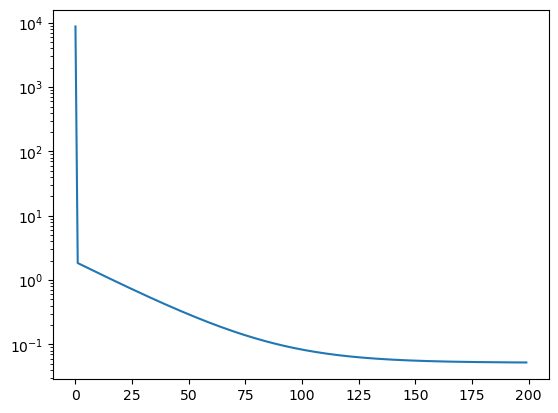

In [337]:
plt.plot(costs)
plt.yscale('log')
plt.show()

In [332]:
theta

array([[ 0.12827132],
       [-0.00053469]])

In [323]:
indices = np.argsort(x[:,0])


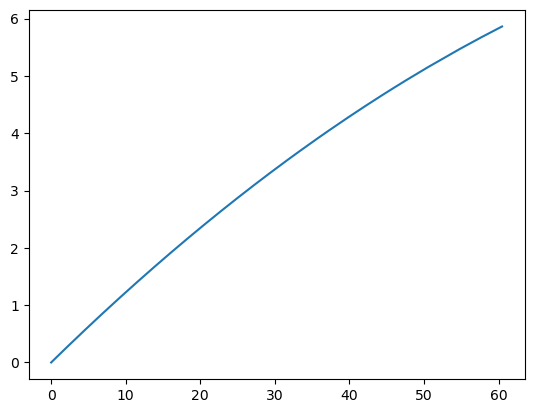

In [338]:
plt.plot(x[indices,0], x[indices].dot(theta))
plt.show()

In [122]:
tt

array([[-9.12667577e+302],
       [-2.68100793e+305],
       [-7.57750433e+303],
       [-3.09204138e+304]])

In [123]:
xt.dot(tt) - yt

array([[            -inf],
       [-9.67148229e+306],
       [-3.70333405e+307],
       [-9.64135541e+307],
       [            -inf],
       [            -inf],
       [-4.65518739e+307],
       [-2.97644828e+307],
       [-4.67220516e+307],
       [-2.88604137e+306]])

In [107]:
xt.T.dot(xt.dot(tt)-yt)

array([[1.95384174e+306],
       [            inf],
       [2.70104058e+307],
       [5.94097797e+307]])